##  Implementation of Association Rule Mining(ARM) on Healthcare Symptom Data Using FP-Growth Algorithm
1. Syarif Sanad - 5025221257
2. Mirza Syahrizal Fathir - 5025231151
3. Aditya Fieansyah Putra Pratama - 5025231309
4. Felda Ega Fadhila - 5025231199

# 1. Setup n Load Data

DATASET OVERVIEW
Total rows        : 92,335
Total columns     : 378
Unique diseases   : 295
Total symptoms    : 377

Symptoms per patient
  Mean   : 5.3
  Median : 5
  Max    : 12

Top 10 symptoms by support:
sharp abdominal pain    0.1309
vomiting                0.1159
nausea                  0.1141
back pain               0.1044
sharp chest pain        0.1023
headache                0.0989
cough                   0.0896
shortness of breath     0.0884
dizziness               0.0877
leg pain                0.0777

Symptom count by support threshold:
  >= 0.050 : 22 symptoms
  >= 0.020 : 101 symptoms
  >= 0.010 : 147 symptoms
  >= 0.005 : 189 symptoms


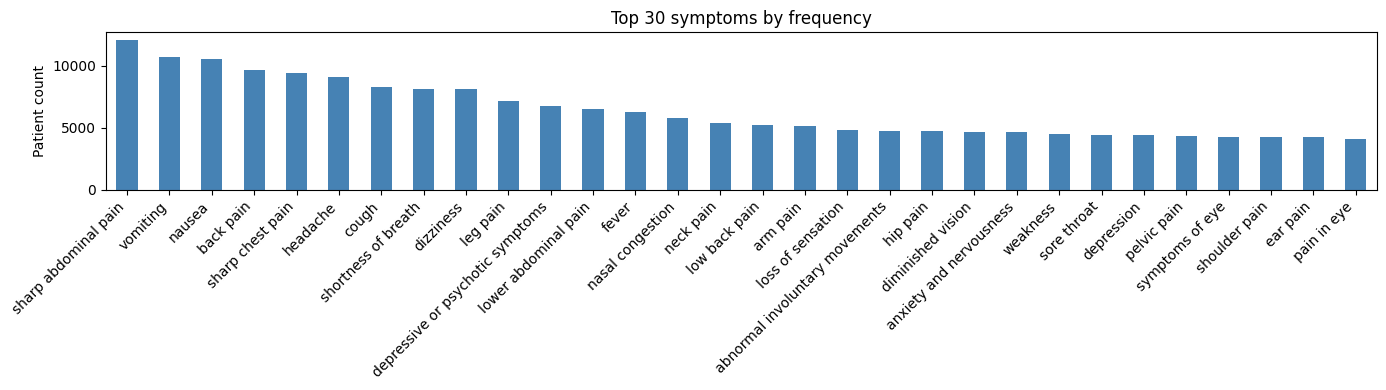

In [2]:
!pip install mlxtend --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import re

# config
FILE_PATH          = '/content/Final_Augmented_dataset_Diseases_and_Symptoms.csv'
TARGET_COL         = 'diseases'
TOP_N_PLOT         = 30
MIN_SUPPORT_FILTER = 0.01   # keep symptoms in >= 1% of all patients
MAX_SUPPORT_FILTER = 0.95   # remove symptoms in >= 95% of all patients

# Load-
df           = pd.read_csv(FILE_PATH)
symptom_cols = [c for c in df.columns if c != TARGET_COL]

# Basic Info
print("DATASET OVERVIEW")
print(f"Total rows        : {len(df):,}")
print(f"Total columns     : {df.shape[1]}")
print(f"Unique diseases   : {df[TARGET_COL].nunique()}")
print(f"Total symptoms    : {len(symptom_cols)}")

# Sympton Statistics
symptoms_per_patient = df[symptom_cols].sum(axis=1)
print(f"\nSymptoms per patient")
print(f"  Mean   : {symptoms_per_patient.mean():.1f}")
print(f"  Median : {symptoms_per_patient.median():.0f}")
print(f"  Max    : {symptoms_per_patient.max():.0f}")

# Frequency & Support
freq    = df[symptom_cols].sum().sort_values(ascending=False)
support = freq / len(df)

print(f"\nTop 10 symptoms by support:")
print(support.head(10).round(4).to_string())

print(f"\nSymptom count by support threshold:")
for t in [0.05, 0.02, 0.01, 0.005]:
    print(f"  >= {t:.3f} : {(support >= t).sum()} symptoms")

# Plot
freq.head(TOP_N_PLOT).plot(
    kind='bar', figsize=(14, 4),
    title=f'Top {TOP_N_PLOT} symptoms by frequency',
    color='steelblue'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Patient count')
plt.tight_layout()
plt.savefig('top_symptoms.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Preprocessing

In [3]:
support = df[symptom_cols].sum() / len(df)

# remove too rare symptoms
too_rare        = support[support < MIN_SUPPORT_FILTER].index.tolist()
active_symptoms = support[support >= MIN_SUPPORT_FILTER].index.tolist()

# remove too commons symptoms
too_common      = [c for c in active_symptoms if support[c] > MAX_SUPPORT_FILTER]
active_symptoms = [c for c in active_symptoms if c not in too_common]

# remove duplicate columns
duplicate_cols  = [c for c in active_symptoms if re.search(r'\.\d+$', c)]
active_symptoms = [c for c in active_symptoms if c not in duplicate_cols]

print("PREPROCESSING")
print(f"Original symptoms    : {len(symptom_cols)}")
print(f"Too rare  (< {MIN_SUPPORT_FILTER:.0%})  : {len(too_rare)}")
print(f"Too common (> {MAX_SUPPORT_FILTER:.0%}) : {len(too_common)}")
print(f"Duplicates removed   : {duplicate_cols}")
print(f"Final symptoms used  : {len(active_symptoms)}")

# save diseases columnn, convert to boolean
diseases_series = df[TARGET_COL].copy()
df_bool         = df[active_symptoms].astype(bool)

print(f"\nDataframe shape : {df_bool.shape}")
print(f"Memory usage    : {df_bool.memory_usage(deep=True).sum() / 1e6:.1f} MB")

del df
gc.collect()
print("\nOriginal dataframe removed from memory. Ready for mining.")

PREPROCESSING
Original symptoms    : 377
Too rare  (< 1%)  : 230
Too common (> 95%) : 0
Duplicates removed   : ['regurgitation.1']
Final symptoms used  : 146

Dataframe shape : (92335, 146)
Memory usage    : 13.5 MB

Original dataframe removed from memory. Ready for mining.


# 3. FP-Growth

In [4]:
from mlxtend.frequent_patterns import fpgrowth

# config
MIN_SUPPORT = 0.01
MAX_ITEMSET = 3

print("FP-GROWTH")
print(f"Min support : {MIN_SUPPORT}")
print(f"Max itemset : {MAX_ITEMSET}")
print("Running... (may take 2-10 minutes)\n")

frequent_itemsets          = fpgrowth(
    df_bool,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_ITEMSET,
    verbose=1
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"\nFrequent itemsets found : {len(frequent_itemsets):,}")
print(f"\nItemset length distribution:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())
print(f"\nTop 10 by support:")
print(
    frequent_itemsets
    .sort_values('support', ascending=False)
    .head(10)
    .to_string(index=False)
)

FP-GROWTH
Min support : 0.01
Max itemset : 3
Running... (may take 2-10 minutes)



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

146 itemset(s) from tree conditioned on items ()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

4 itemset(s) from tree conditioned on items (shortness of breath)
0 itemset(s) from tree conditioned on items (shortness of breath, sharp chest pain)
0 itemset(s) from tree conditioned on items (shortness of breath, cough)
0 itemset(s) from tree conditioned on items (shortness of breath, vomiting)
0 itemset(s) from tree conditioned on items (shortness of breath, nausea)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


1 itemset(s) from tree conditioned on items (skin lesion)
0 itemset(s) from tree conditioned on items (sweating)
0 itemset(s) from tree conditioned on items (bones are painful)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

2 itemset(s) from tree conditioned on items (knee swelling)
0 itemset(s) from tree conditioned on items (knee swelling, knee pain)
0 itemset(s) from tree conditioned on items (knee swelling, leg swelling)
0 itemset(s) from tree conditioned on items (too little hair)
1 itemset(s) from tree conditioned on items (skin rash)
0 itemset(s) from tree conditioned on items (mouth ulcer)
0 itemset(s) from tree conditioned on items (elbow swelling)
0 itemset(s) from tree conditioned on items (melena)
0 itemset(s) from tree conditioned on items (eye burns or stings)
0 itemset(s) from tree conditioned on items (fluid in ear)
0 itemset(s) from tree conditioned on items (low self-esteem)
0 itemset(s) from tree conditioned on items (fears and phobias)
0 itemset(s) from tree conditioned on items (heartburn)
0 itemset(s) from tree conditioned on items (rectal bleeding)
0 itemset(s) from tree conditioned on items (rib pain)
0 itemset(s) from tree conditioned on items (ankle swelling)
0 itemset(s) from tr

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 4. Association Rules (Global)

In [5]:
from mlxtend.frequent_patterns import association_rules

# config
MIN_CONFIDENCE = 0.30
MIN_LIFT       = 1.20

# generate
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)

print("ASSOCIATION RULES — GLOBAL")
print(f"Rules before filters : {len(rules):,}")

# filter by lift
rules = rules[rules['lift'] >= MIN_LIFT].copy()
print(f"After lift filter    : {len(rules):,}")

# add readable columns
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules['antecedents_len'] = rules['antecedents'].apply(len)
rules['consequents_len'] = rules['consequents'].apply(len)

# Zhang's metric (positive correlation filter)
def zhangs_metric(r):
    num = r['support'] - r['antecedent support'] * r['consequent support']
    den = np.maximum(
        r['support'] * (1 - r['antecedent support']),
        r['antecedent support'] * (r['consequent support'] - r['support'])
    )
    return num / den

rules['zhang'] = zhangs_metric(rules)
rules          = rules[rules['zhang'] > 0].copy()
print(f"After Zhang filter   : {len(rules):,}")

# remove duplicate column rules
def contains_duplicate(s, dup_list):
    return any(d in s for d in dup_list)

dup_mask    = ~(
    rules['antecedents_str'].apply(lambda s: contains_duplicate(s, duplicate_cols)) |
    rules['consequents_str'].apply(lambda s: contains_duplicate(s, duplicate_cols))
)
rules_clean = rules[dup_mask].copy().reset_index(drop=True)
print(f"After dup removal    : {len(rules_clean):,}")

# sort
rules_clean = rules_clean.sort_values(
    ['lift', 'confidence'], ascending=False
).reset_index(drop=True)

display_cols = [
    'antecedents_str', 'consequents_str',
    'support', 'confidence', 'lift', 'conviction', 'zhang'
]
print(f"\nTop 15 rules:")
print(rules_clean[display_cols].head(15).to_string(index=False))

# export
export_cols = display_cols + ['leverage', 'antecedents_len', 'consequents_len']
rules_clean[export_cols].to_csv('association_rules_global.csv', index=False)
print("\nSaved: association_rules_global.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

ASSOCIATION RULES — GLOBAL
Rules before filters : 249
After lift filter    : 249
After Zhang filter   : 249
After dup removal    : 249

Top 15 rules:
              antecedents_str               consequents_str  support  confidence      lift  conviction    zhang
             hostile behavior                    drug abuse 0.010722    0.536876 22.012646    2.106588 0.974024
                   drug abuse              hostile behavior 0.010722    0.439609 22.012646    1.748832 0.978435
      hand or finger swelling                wrist swelling 0.010397    0.460874 19.238145    1.810418 0.969900
               wrist swelling       hand or finger swelling 0.010397    0.433996 19.238145    1.726916 0.971288
               wrist swelling                    wrist pain 0.011718    0.489150 18.322788    1.905264 0.968628
                   wrist pain                wrist swelling 0.011718    0.438945 18.322788    1.739659 0.971355
foreign body sensation in eye     spots or clouds in vision 0.0159

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

5. Per disease mining

In [6]:
# config
# Leave empty [] to auto-select top 10 diseases by patient count
TARGET_DISEASES        = []
MIN_PATIENTS_PER_CLASS = 200
MIN_SUPPORT_LOCAL      = 0.05
MIN_CONFIDENCE_LOCAL   = 0.40
MIN_LIFT_LOCAL         = 1.50
MAX_ITEMSET_LOCAL      = 3

# auto select diseases if none specified
if not TARGET_DISEASES:
    TARGET_DISEASES = (
        diseases_series.value_counts()
        .loc[lambda x: x >= MIN_PATIENTS_PER_CLASS]
        .head(10)
        .index.tolist()
    )
    print(f"Auto-selected {len(TARGET_DISEASES)} diseases:")
    print(TARGET_DISEASES)

# mine per diseased
all_disease_rules = []

for disease in TARGET_DISEASES:
    idx    = diseases_series[diseases_series == disease].index
    df_sub = df_bool.loc[idx]

    if len(df_sub) < MIN_PATIENTS_PER_CLASS:
        print(f"Skipping '{disease}': only {len(df_sub)} patients")
        continue

    fi           = fpgrowth(
        df_sub,
        min_support=MIN_SUPPORT_LOCAL,
        use_colnames=True,
        max_len=MAX_ITEMSET_LOCAL,
        verbose=0
    )
    fi['length'] = fi['itemsets'].apply(len)

    if fi[fi['length'] >= 2].empty:
        print(f"  [{disease}] No multi-item itemsets found — skip")
        continue

    r = association_rules(
        fi,
        metric="confidence",
        min_threshold=MIN_CONFIDENCE_LOCAL
    )
    r = r[r['lift'] >= MIN_LIFT_LOCAL].copy()

    if r.empty:
        print(f"  [{disease}] No rules passed filters — skip")
        continue

    r['zhang']           = zhangs_metric(r)
    r                    = r[r['zhang'] > 0].copy()
    r['disease']         = disease
    r['antecedents_str'] = r['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    r['consequents_str'] = r['consequents'].apply(lambda x: ', '.join(sorted(x)))
    all_disease_rules.append(r)
    print(f"  [{disease}] {len(df_sub):,} patients -> {len(r)} rules")

# combine & export
if all_disease_rules:
    rules_by_disease = (
        pd.concat(all_disease_rules, ignore_index=True)
        .sort_values(['disease', 'lift'], ascending=[True, False])
        .reset_index(drop=True)
    )

    disease_display_cols = [
        'disease', 'antecedents_str', 'consequents_str',
        'support', 'confidence', 'lift', 'conviction', 'zhang'
    ]
    rules_by_disease[disease_display_cols].to_csv(
        'association_rules_by_disease.csv', index=False
    )
    print(f"\nTotal disease-specific rules : {len(rules_by_disease):,}")
    print(f"Saved: association_rules_by_disease.csv")
    print(f"\nTop 20 rules across all diseases:")
    print(
        rules_by_disease[disease_display_cols]
        .sort_values('lift', ascending=False)
        .head(20)
        .to_string(index=False)
    )
else:
    print("No disease-specific rules found. Try lowering thresholds.")

Auto-selected 10 diseases:
['vulvodynia', 'complex regional pain syndrome', 'spondylosis', 'vaginal cyst', 'conjunctivitis due to allergy', 'hypoglycemia', 'gastrointestinal hemorrhage', 'pneumonia', 'infectious gastroenteritis', 'gout']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  [vulvodynia] No rules passed filters — skip


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  [complex regional pain syndrome] No rules passed filters — skip


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  [infectious gastroenteritis] No rules passed filters — skip


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  [gout] No rules passed filters — skip
No disease-specific rules found. Try lowering thresholds.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 6. Visualization, Heatmap & Narratives

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

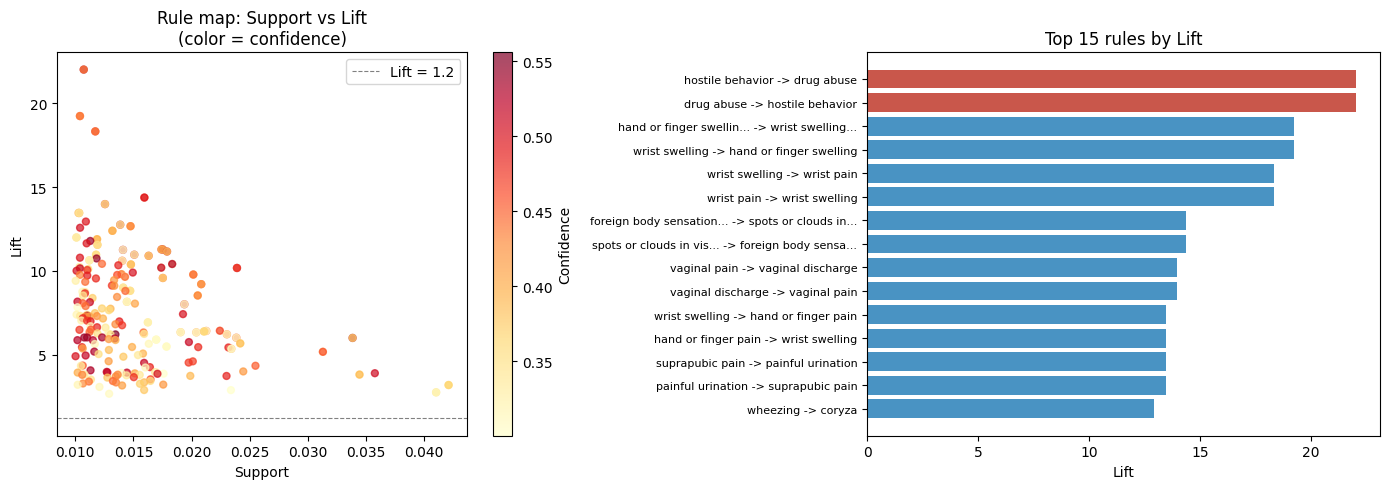

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

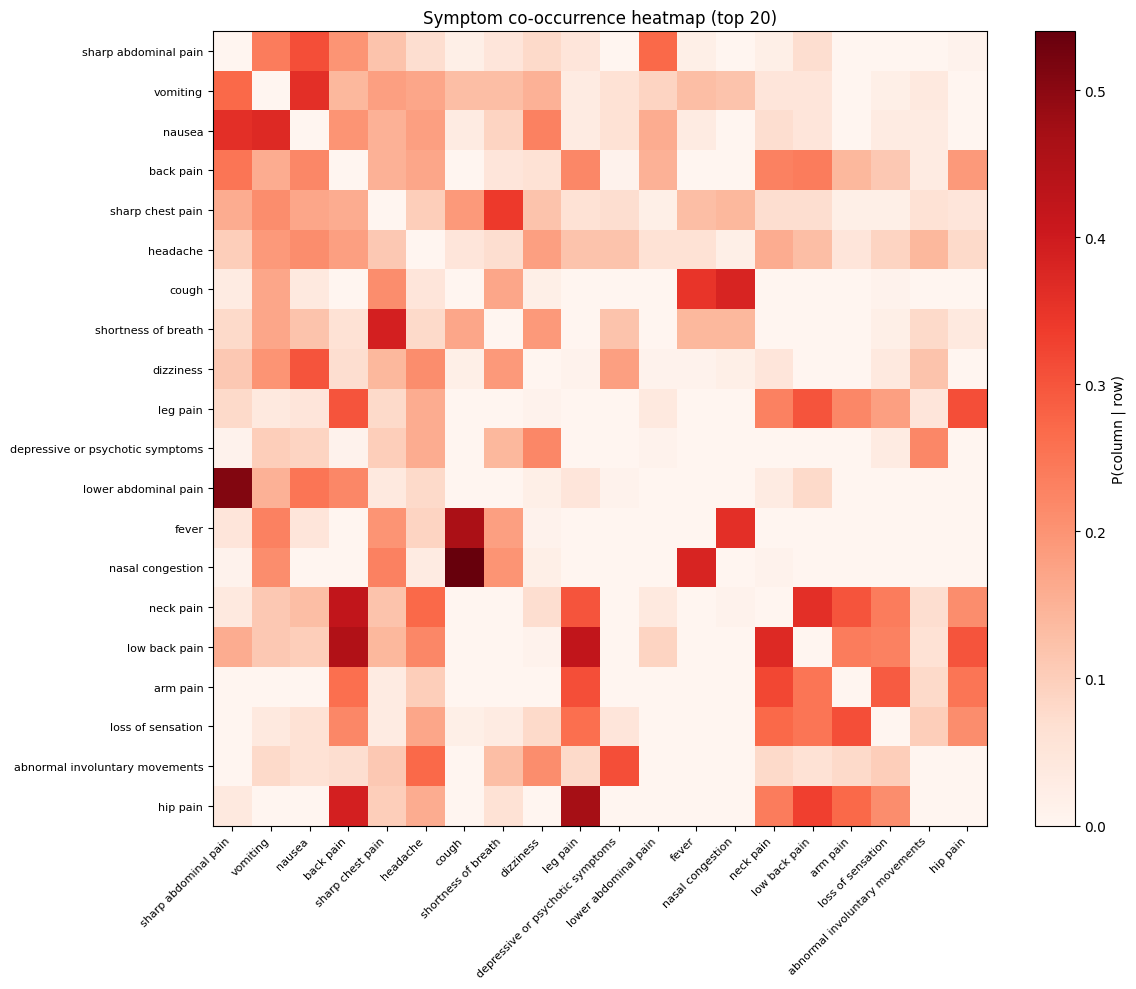

RULE NARRATIVES
Rule 1: [hostile behavior] => [drug abuse]
  Support    : 0.0107  (1.07% of 92,335 patients)
  Confidence : 0.537  ('drug abuse' appears 53.7% of the time when 'hostile behavior' is present)
  Lift       : 22.013  (strongly stronger than random co-occurrence)
  Conviction : 2.107  (high directional dependency)
  Zhang      : 0.974  (positive = confirmed positive correlation)

Rule 2: [drug abuse] => [hostile behavior]
  Support    : 0.0107  (1.07% of 92,335 patients)
  Confidence : 0.440  ('hostile behavior' appears 44.0% of the time when 'drug abuse' is present)
  Lift       : 22.013  (strongly stronger than random co-occurrence)
  Conviction : 1.749  (moderate directional dependency)
  Zhang      : 0.978  (positive = confirmed positive correlation)

Rule 3: [hand or finger swelling] => [wrist swelling]
  Support    : 0.0104  (1.04% of 92,335 patients)
  Confidence : 0.461  ('wrist swelling' appears 46.1% of the time when 'hand or finger swelling' is present)
  Lift   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
TOP_N_HEATMAP = 20
TOP_N_REPORT  = 10

# plot 1: global rule map + top 15 bar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sc  = ax1.scatter(
    rules_clean['support'],
    rules_clean['lift'],
    c=rules_clean['confidence'],
    cmap='YlOrRd', alpha=0.7, s=25
)
plt.colorbar(sc, ax=ax1, label='Confidence')
ax1.axhline(
    y=MIN_LIFT, color='gray',
    linestyle='--', linewidth=0.8,
    label=f'Lift = {MIN_LIFT}'
)
ax1.set_xlabel('Support')
ax1.set_ylabel('Lift')
ax1.set_title('Rule map: Support vs Lift\n(color = confidence)')
ax1.legend()

ax2    = axes[1]
top15  = rules_clean.head(15)
labels = [
    f"{a[:22]}... -> {c[:18]}..." if len(a) > 22 else f"{a} -> {c}"
    for a, c in zip(top15['antecedents_str'], top15['consequents_str'])
]
colors = ['#c0392b' if l > 20 else '#2980b9' for l in top15['lift']]
ax2.barh(range(len(top15)), top15['lift'].values, color=colors, alpha=0.85)
ax2.set_yticks(range(len(top15)))
ax2.set_yticklabels(labels, fontsize=8)
ax2.set_xlabel('Lift')
ax2.set_title('Top 15 rules by Lift')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('arm_results_global.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: co-occurence heatmap
top_symptoms = (
    df_bool.sum()
    .sort_values(ascending=False)
    .head(TOP_N_HEATMAP)
    .index.tolist()
)

cooc      = df_bool[top_symptoms].astype(int).T.dot(
                df_bool[top_symptoms].astype(int))
cooc_norm = cooc.div(cooc.values.diagonal(), axis=0).round(2)
np.fill_diagonal(cooc_norm.values, 0)

fig, ax = plt.subplots(figsize=(12, 10))
im      = ax.imshow(cooc_norm.values, cmap='Reds', aspect='auto')
plt.colorbar(im, ax=ax, label='P(column | row)')
ax.set_xticks(range(TOP_N_HEATMAP))
ax.set_yticks(range(TOP_N_HEATMAP))
ax.set_xticklabels(top_symptoms, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(top_symptoms, fontsize=8)
ax.set_title(f'Symptom co-occurrence heatmap (top {TOP_N_HEATMAP})')
plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Per-disease top rules
if all_disease_rules:
    top_disease_rules = (
        rules_by_disease
        .sort_values('lift', ascending=False)
        .head(15)
    )
    labels_d = [
        f"[{d}] {a[:18]}... -> {c[:15]}..."
        if len(a) > 18 else f"[{d}] {a} -> {c}"
        for d, a, c in zip(
            top_disease_rules['disease'],
            top_disease_rules['antecedents_str'],
            top_disease_rules['consequents_str']
        )
    ]
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(
        range(len(top_disease_rules)),
        top_disease_rules['lift'].values,
        color='#8e44ad', alpha=0.85
    )
    ax.set_yticks(range(len(top_disease_rules)))
    ax.set_yticklabels(labels_d, fontsize=8)
    ax.set_xlabel('Lift')
    ax.set_title('Top 15 rules by Lift — per disease')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('arm_results_by_disease.png', dpi=150, bbox_inches='tight')
    plt.show()

# Narratives
print("RULE NARRATIVES")

narrative_lines = []

for i, row in rules_clean.head(TOP_N_REPORT).iterrows():
    ant   = row['antecedents_str']
    con   = row['consequents_str']
    sup   = row['support']
    conf  = row['confidence']
    lift  = row['lift']
    conv  = row['conviction']
    zhang = row['zhang']

    strength  = 'strongly' if lift > 10 else 'moderately'
    dep_level = 'high' if conv > 2 else 'moderate'

    block = (
        f"Rule {i+1}: [{ant}] => [{con}]\n"
        f"  Support    : {sup:.4f}  "
        f"({sup*100:.2f}% of {len(diseases_series):,} patients)\n"
        f"  Confidence : {conf:.3f}  "
        f"('{con}' appears {conf*100:.1f}% of the time when '{ant}' is present)\n"
        f"  Lift       : {lift:.3f}  "
        f"({strength} stronger than random co-occurrence)\n"
        f"  Conviction : {conv:.3f}  ({dep_level} directional dependency)\n"
        f"  Zhang      : {zhang:.3f}  (positive = confirmed positive correlation)\n"
    )
    print(block)
    narrative_lines.append(block)

with open('rule_narratives.txt', 'w') as f:
    f.write('\n'.join(narrative_lines))
print("Saved: rule_narratives.txt")

# Final Summary
print("FINAL SUMMARY")
print(f"Total patients         : {len(diseases_series):,}")
print(f"Symptoms (raw)         : {len(symptom_cols)}")
print(f"Symptoms (filtered)    : {len(active_symptoms)}")
print(f"Min support            : {MIN_SUPPORT}")
print(f"Min confidence         : {MIN_CONFIDENCE}")
print(f"Min lift               : {MIN_LIFT}")
print(f"Frequent itemsets      : {len(frequent_itemsets):,}")
print(f"Global valid rules     : {len(rules_clean):,}")
if all_disease_rules:
    print(f"Disease-specific rules : {len(rules_by_disease):,}")
print(f"Avg support            : {rules_clean['support'].mean():.4f}")
print(f"Avg confidence         : {rules_clean['confidence'].mean():.3f}")
print(f"Avg lift               : {rules_clean['lift'].mean():.3f}")
print(f"Max lift               : {rules_clean['lift'].max():.3f}")